# **Experimenting with Bonsai**

In [1]:
#
# Tell me where Bonsai is
#
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
sys.path.append(str(PROJECT_ROOT / "Bonsai-data-representation"))
sys.path.append(str(Path().resolve().parent))

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from ete3 import Tree

#### **Create some synthetic data (bifurcation, clusters and a closed curve)**

/home/franz/Projects/bonsai-lineage-demo/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


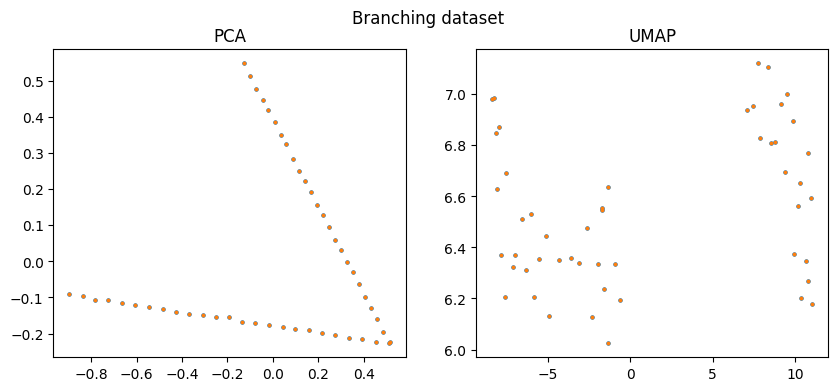

In [2]:
from src.synthetic_data import branching_tree, gaussian_clusters, circular_manifold
from src.visualize import plot_embeddings

# Branching structure
seed = 0
data = branching_tree()

plot_embeddings(data, "Branching dataset", seed)

/home/franz/Projects/bonsai-lineage-demo/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


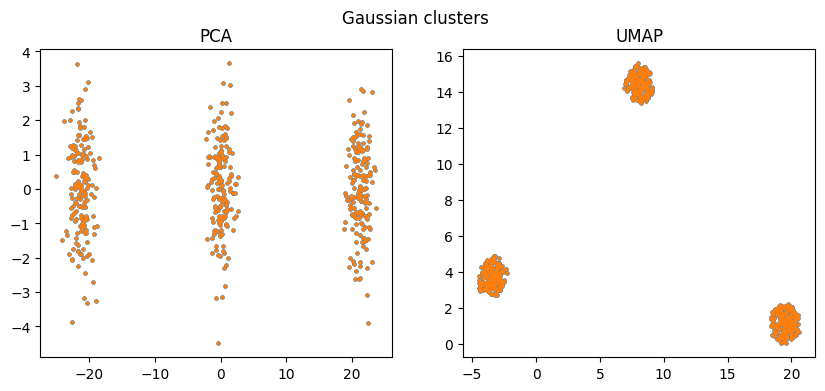

In [3]:
# Cluster structure
data = gaussian_clusters()

plot_embeddings(data, "Gaussian clusters", 0)

/home/franz/Projects/bonsai-lineage-demo/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


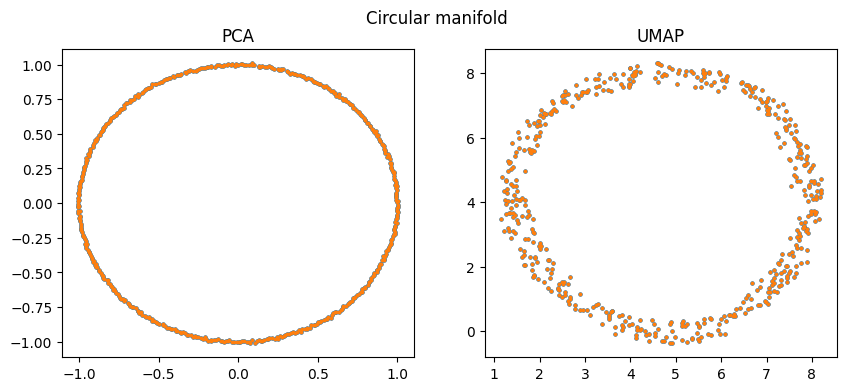

In [4]:
# Circular structure
data = circular_manifold()

plot_embeddings(data, "Circular manifold", 0)

#### **Distance preservation in the embedding on the synthetic data**

In [5]:
from src.synthetic_data import branching_tree
from src.visualize import compute_embeddings
from src.evaluate import distance_preservation, per_point_distance_preservation

In [6]:
data = branching_tree()

pca, um = compute_embeddings(data) 

corr_pca = distance_preservation(data, pca)
corr_umap = distance_preservation(data, um)

print("Distance preservation:")
print("PCA:", corr_pca)
print("UMAP:", corr_umap)

Distance preservation:
PCA: 0.9981211099847489
UMAP: 0.789730621423433


In [7]:
corrs_pca = per_point_distance_preservation(data, pca)
corrs_umap = per_point_distance_preservation(data, um)

print("PCA mean:", corrs_pca.mean())
print("UMAP mean:", corrs_umap.mean())

PCA mean: 0.9979077963110942
UMAP mean: 0.8328090313298024


In [8]:
datasets = {
    "branching": branching_tree(),
    "clusters": gaussian_clusters(),
    "circle": circular_manifold()
}

results = {}

for name, data in datasets.items():

    pca, um = compute_embeddings(data)

    results[name] = {
        "PCA": per_point_distance_preservation(data, pca),
        "UMAP": per_point_distance_preservation(data, um)
    }

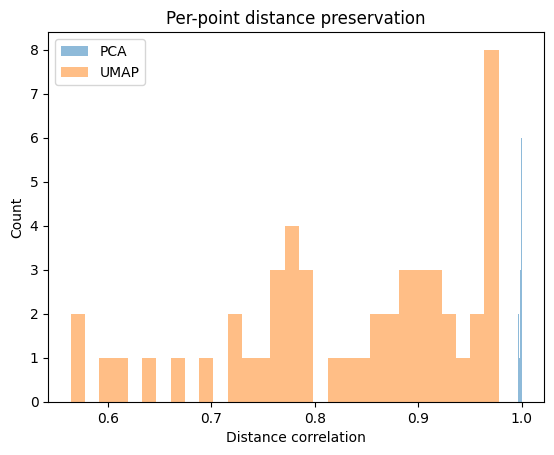

In [9]:

plt.hist(corrs_pca, bins=30, alpha=0.5, label="PCA")
plt.hist(corrs_umap, bins=30, alpha=0.5, label="UMAP")

plt.legend()
plt.xlabel("Distance correlation")
plt.ylabel("Count")

plt.title("Per-point distance preservation")

plt.show()

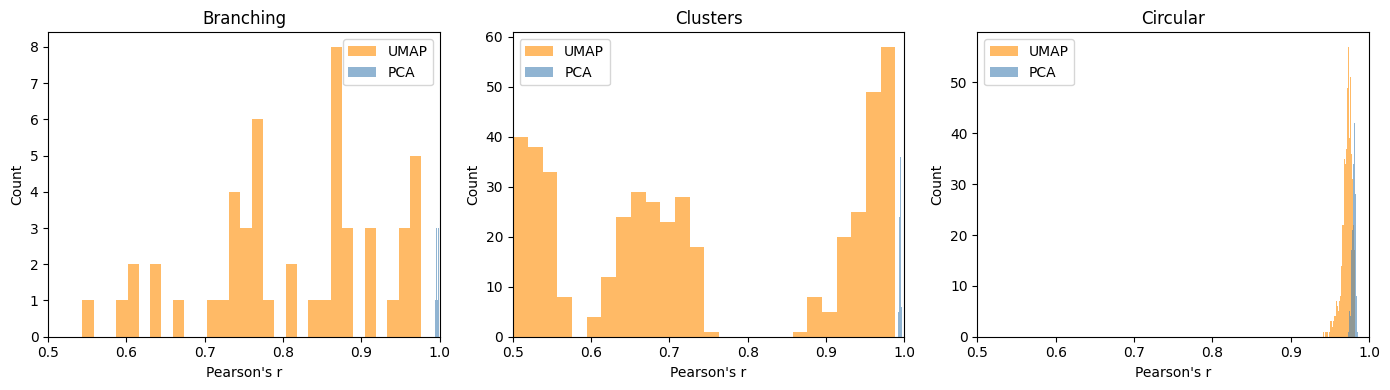

In [10]:
from src.synthetic_data import branching_tree, gaussian_clusters, circular_manifold
from src.visualize import compute_embeddings
from src.evaluate import per_point_distance_preservation

#
# Recreate Figure 2 of the Bonsai paper
#

datasets = {
    "Branching": branching_tree(),
    "Clusters": gaussian_clusters(),
    "Circular": circular_manifold()
}


fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (name, data) in zip(axes, datasets.items()):

    pca, um = compute_embeddings(data)

    corr_pca = per_point_distance_preservation(data, pca)
    corr_umap = per_point_distance_preservation(data, um)

    ax.set_xlim(0.5, 1)

    ax.hist(corr_umap, bins=30, alpha=0.6, color="darkorange", label="UMAP")
    ax.hist(corr_pca, bins=30, alpha=0.6, color="steelblue", label="PCA")
    
    ax.set_title(name)
    ax.set_xlabel("Pearson's r")
    ax.set_ylabel("Count")
    ax.legend()


plt.tight_layout()
plt.show()

# **1. Generate a synthetic branching dataset**

Number of genes: 40
Genes passing z-score cutoff: 6


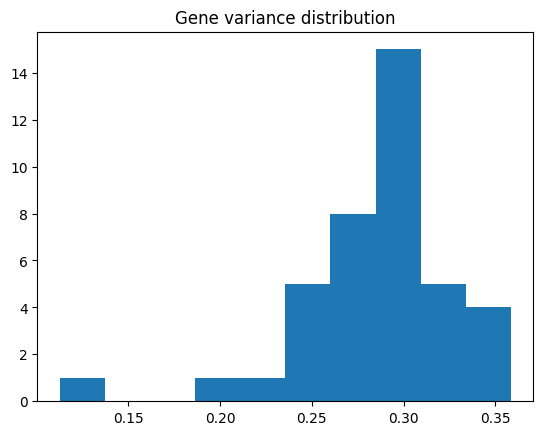

/home/franz/Projects/bonsai-lineage-demo/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


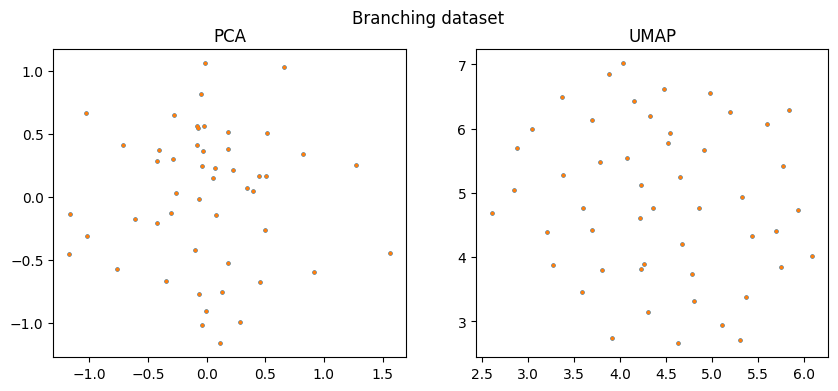

In [11]:
from src.synthetic_data import bonsai_gene_diagnostic, branching_tree_curved, branching_tree_structured, gaussian_clusters, circular_manifold
from src.visualize import compute_embeddings, plot_embeddings

#
# Find usable input data for Bonsai
#

# seed = 49
# data = branching_tree_curved(n_points=40, dim=4, noise=0.02, seed=seed)
# seed = 30
# data = branching_tree_curved(n_points=40, dim=4, noise=0.1, seed=seed)

# seed = 30
# noise = 0.14
# data = branching_tree_curved(n_points=40, dim=4, noise=noise, seed=seed)

seed = 43
noise = 0.02
data = branching_tree_structured(n_points=50, dim=40, noise=noise, seed=seed)

# should show at least 5-10 surviving genes
bonsai_gene_diagnostic(data)

# Check the histogram.
# If the histogram is very narrow, Bonsai will filter aggressively.
plt.hist(np.std(data, axis=0))
plt.title("Gene variance distribution")
plt.show()

plot_embeddings(data, "Branching dataset",seed)

# **2. Compute PCA and UMAP embeddings**

In [12]:
pca, um = compute_embeddings(data)

# **3. Run the Bonsai lineage inference pipeline**

In [14]:
from src.bonsai_wrapper import run_bonsai
print(type(data))
D_bonsai = run_bonsai(data, "..")

<class 'numpy.ndarray'>


03-14 07:17:36 mp_print WARNING The argument 'skip_opt_times' is deprecated and no longer have any effect. Use --pickup_intermediate True to pick up intermediate results from previous Bonsai runs.
03-14 07:17:36 mp_print WARNING The argument 'skip_redo_starry' is deprecated and no longer have any effect. Use --pickup_intermediate True to pick up intermediate results from previous Bonsai runs.
03-14 07:17:36 mp_print WARNING The argument 'skip_nnn_reordering' is deprecated and no longer have any effect. Use --pickup_intermediate True to pick up intermediate results from previous Bonsai runs.


Since the mpi4py-package is not installed, parallel computation is not possible. This package does not work properly on Windows, but can be installed on other operating systems.
DDD getattr(args, "--force_restart", True): True


03-14 07:17:37 mp_print INFO Process 0: Process 0 out of 1 has started.
03-14 07:17:37 mp_print INFO Processed 40 genes in 0.03 seconds, found 50 cells. At zscore-cutoff of 1.000000, 39 genes were kept.
03-14 07:17:37 mp_print INFO No geneID-file was found. Giving generic names.
03-14 07:17:37 mp_print INFO No cellID-file was found. Giving generic names.
03-14 07:17:37 mp_print INFO Max absolute change in ti was: 0.4936370037039486
03-14 07:17:37 mp_print INFO Max absolute change in ti was: 0.03669064882992101
03-14 07:17:37 mp_print INFO Max absolute change in ti was: 0.00310354474113117
03-14 07:17:37 mp_print INFO Max absolute change in ti was: 0.0003685675069668992
03-14 07:17:37 mp_print INFO Max absolute change in ti was: 0.00011317233129126691
03-14 07:17:37 mp_print INFO Max absolute change in ti was: 0.0
03-14 07:17:37 mp_print INFO LogL per Gene: -59.274147558939966
03-14 07:17:37 mp_print INFO Initial optimisation of times with EM took 0.01306915283203125 seconds.
03-14 07:1

# **4. Visualize the inferred lineage structure**

In [15]:
tree_path = "../bonsai_results/intermediate_bonsai_zscore1.0_redoStarry_tmpStartbonsai_tmp/tree.nwk"
tree = Tree(tree_path, format=1)

print(tree.get_ascii(show_internal=True))


              /-Cell_30
    /internal_0
   |          \-Cell_31
   |
   |                    /-Cell_10
   |                   |
   |          /internal_2         /-Cell_1
   |         |         |         |
   |         |          \internal_3                   /-Cell_13
   |         |                   |          /internal_5
   |         |                   |         |          \-Cell_43
   |         |                    \internal_4
   |         |                             |          /-Cell_0
   |         |                              \internal_6
   |         |                                       |          /-Cell_40
   |         |                                        \internal_7
   |         |                                                 |          /-Cell_11
   |         |                                                  \internal_8
   |         |                                                           |          /-Cell_6
   |         |                                     

In [16]:
# build a list of *main* branches, directly connected to root
def extract_main_branches(tree):

    root = tree.get_tree_root()

    branches = []

    for child in root.children:

        leaves = [leaf.name for leaf in child.iter_leaves()]

        branches.append(leaves)

    return branches

# test
branches = extract_main_branches(tree)

for i, branch in enumerate(branches):
    print(f"Branch {i+1} ({len(branch)} cells):")
    print(branch[:10], "...")   # preview first few cells

Branch 1 (2 cells):
['Cell_30', 'Cell_31'] ...
Branch 2 (28 cells):
['Cell_10', 'Cell_1', 'Cell_13', 'Cell_43', 'Cell_0', 'Cell_40', 'Cell_11', 'Cell_6', 'Cell_25', 'Cell_24'] ...
Branch 3 (20 cells):
['Cell_3', 'Cell_15', 'Cell_42', 'Cell_16', 'Cell_29', 'Cell_5', 'Cell_33', 'Cell_37', 'Cell_12', 'Cell_39'] ...


In [17]:
# reduce the Bonsai tree by only preserving the backbone
# idea:
#       node with    2 children --> continuation of a branch --> can collapse
#       node with >= 3 children --> real branching point --> keep

def subtree_size(node):
    return len(node.get_leaves())

# identify backbone nodes
def backbone_nodes(tree, min_size=5):

    nodes = []

    for node in tree.traverse():

        size = subtree_size(node)

        if node.is_root():
            nodes.append(node)

        elif node.is_leaf():
            nodes.append(node)

        elif size >= min_size:
            nodes.append(node)

    return nodes

# test
bb_nodes = backbone_nodes(tree, min_size=8)
print("Backbone nodes:", len(bb_nodes))

# print simplified structure
for n in bb_nodes:

    leaves = [l.name for l in n.get_leaves()[:5]]

    print(
        f"{n.name:12s}",
        "size =", subtree_size(n),
        "example leaves:", leaves
    )

# visualize the backbone only
important_edges = []

for node in bb_nodes:

    for child in node.children:

        if child in bb_nodes:
            important_edges.append((node.name, child.name))

print(f"important edges:\n{important_edges}")
for edge in important_edges:
    print(f"{edge[0]} --> {edge[1]}")

Backbone nodes: 60
root         size = 50 example leaves: ['Cell_30', 'Cell_31', 'Cell_10', 'Cell_1', 'Cell_13']
internal_1   size = 28 example leaves: ['Cell_10', 'Cell_1', 'Cell_13', 'Cell_43', 'Cell_0']
internal_27  size = 20 example leaves: ['Cell_3', 'Cell_15', 'Cell_42', 'Cell_16', 'Cell_29']
Cell_30      size = 1 example leaves: ['Cell_30']
Cell_31      size = 1 example leaves: ['Cell_31']
internal_2   size = 9 example leaves: ['Cell_10', 'Cell_1', 'Cell_13', 'Cell_43', 'Cell_0']
internal_10  size = 19 example leaves: ['Cell_24', 'Cell_49', 'Cell_14', 'Cell_22', 'Cell_27']
internal_28  size = 14 example leaves: ['Cell_3', 'Cell_15', 'Cell_42', 'Cell_16', 'Cell_29']
Cell_10      size = 1 example leaves: ['Cell_10']
internal_3   size = 8 example leaves: ['Cell_1', 'Cell_13', 'Cell_43', 'Cell_0', 'Cell_40']
internal_11  size = 13 example leaves: ['Cell_24', 'Cell_49', 'Cell_14', 'Cell_22', 'Cell_27']
internal_29  size = 8 example leaves: ['Cell_3', 'Cell_15', 'Cell_42', 'Cell_16', 

In [18]:
# print the full tree in ascii format
def print_full_tree_ascii(tree, backbone_nodes):

    backbone_set = set(backbone_nodes)
    root = tree.get_tree_root()

    def collapse_chain(node):
        """
        Follow nodes until we reach another backbone node or a leaf.
        Return the chain of names.
        """
        chain = [node.name]

        while node not in backbone_set and not node.is_leaf() and len(node.children) == 1:
            node = node.children[0]
            chain.append(node.name)

        return node, chain

    def recurse(node, prefix=""):

        children = node.children

        for i, child in enumerate(children):

            collapsed_node, chain = collapse_chain(child)

            chain_str = " -- ".join(chain)

            connector = "|-- "

            print(prefix + connector + chain_str)

            if not collapsed_node.is_leaf():
                recurse(collapsed_node, prefix + "|   ")

    print("root")
    recurse(root, "  ")

# test
bb_nodes = backbone_nodes(tree, min_size=8)

print_full_tree_ascii(tree, bb_nodes)

root
  |-- internal_0
  |   |-- Cell_30
  |   |-- Cell_31
  |-- internal_1
  |   |-- internal_2
  |   |   |-- Cell_10
  |   |   |-- internal_3
  |   |   |   |-- Cell_1
  |   |   |   |-- internal_4
  |   |   |   |   |-- internal_5
  |   |   |   |   |   |-- Cell_13
  |   |   |   |   |   |-- Cell_43
  |   |   |   |   |-- internal_6
  |   |   |   |   |   |-- Cell_0
  |   |   |   |   |   |-- internal_7
  |   |   |   |   |   |   |-- Cell_40
  |   |   |   |   |   |   |-- internal_8
  |   |   |   |   |   |   |   |-- Cell_11
  |   |   |   |   |   |   |   |-- internal_9
  |   |   |   |   |   |   |   |   |-- Cell_6
  |   |   |   |   |   |   |   |   |-- Cell_25
  |   |-- internal_10
  |   |   |-- internal_11
  |   |   |   |-- internal_12
  |   |   |   |   |-- internal_13
  |   |   |   |   |   |-- Cell_24
  |   |   |   |   |   |-- internal_14
  |   |   |   |   |   |   |-- Cell_49
  |   |   |   |   |   |   |-- internal_15
  |   |   |   |   |   |   |   |-- Cell_14
  |   |   |   |   |   |   |   |-- Ce

In [19]:
# print only the backbone in ascii

# build the graph of the backbone from only the important_edges
backbone_graph = nx.DiGraph()
for parent, child in important_edges:
    backbone_graph.add_edge(parent, child)

def print_backbone_ascii(graph, root, prefix=""):

    children = list(graph.successors(root))

    for i, child in enumerate(children):

        connector = "|-- "

        print(prefix + connector + child)

        print_backbone_ascii(graph, child, prefix + "|   ")

# test
print("root")
print_backbone_ascii(backbone_graph, "root")

root
|-- internal_1
|   |-- internal_2
|   |   |-- Cell_10
|   |   |-- internal_3
|   |   |   |-- Cell_1
|   |-- internal_10
|   |   |-- internal_11
|   |   |   |-- internal_12
|   |   |   |   |-- Cell_44
|-- internal_27
|   |-- internal_28
|   |   |-- internal_29
|   |   |   |-- Cell_3


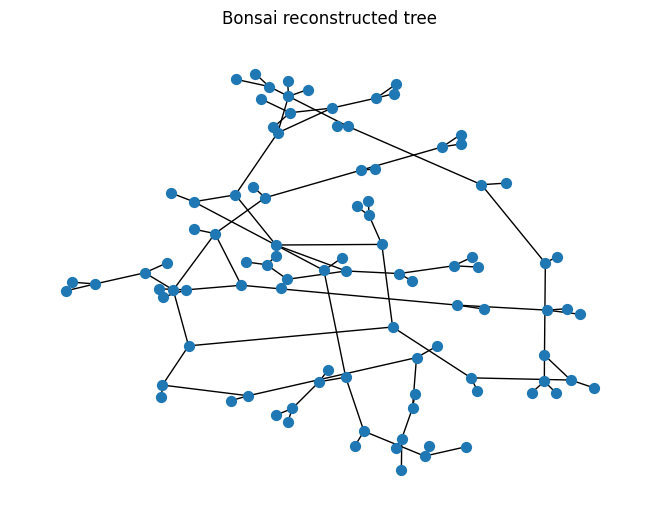

In [20]:
G = nx.Graph()

for node in tree.traverse():
    for child in node.children:
        G.add_edge(node.name, child.name, weight=child.dist)

pos = nx.spring_layout(G)

nx.draw(G, pos, node_size=50, with_labels=False)

plt.title("Bonsai reconstructed tree")
plt.show()

# **Qualitative, visual assessment**

Number of major branches: 2


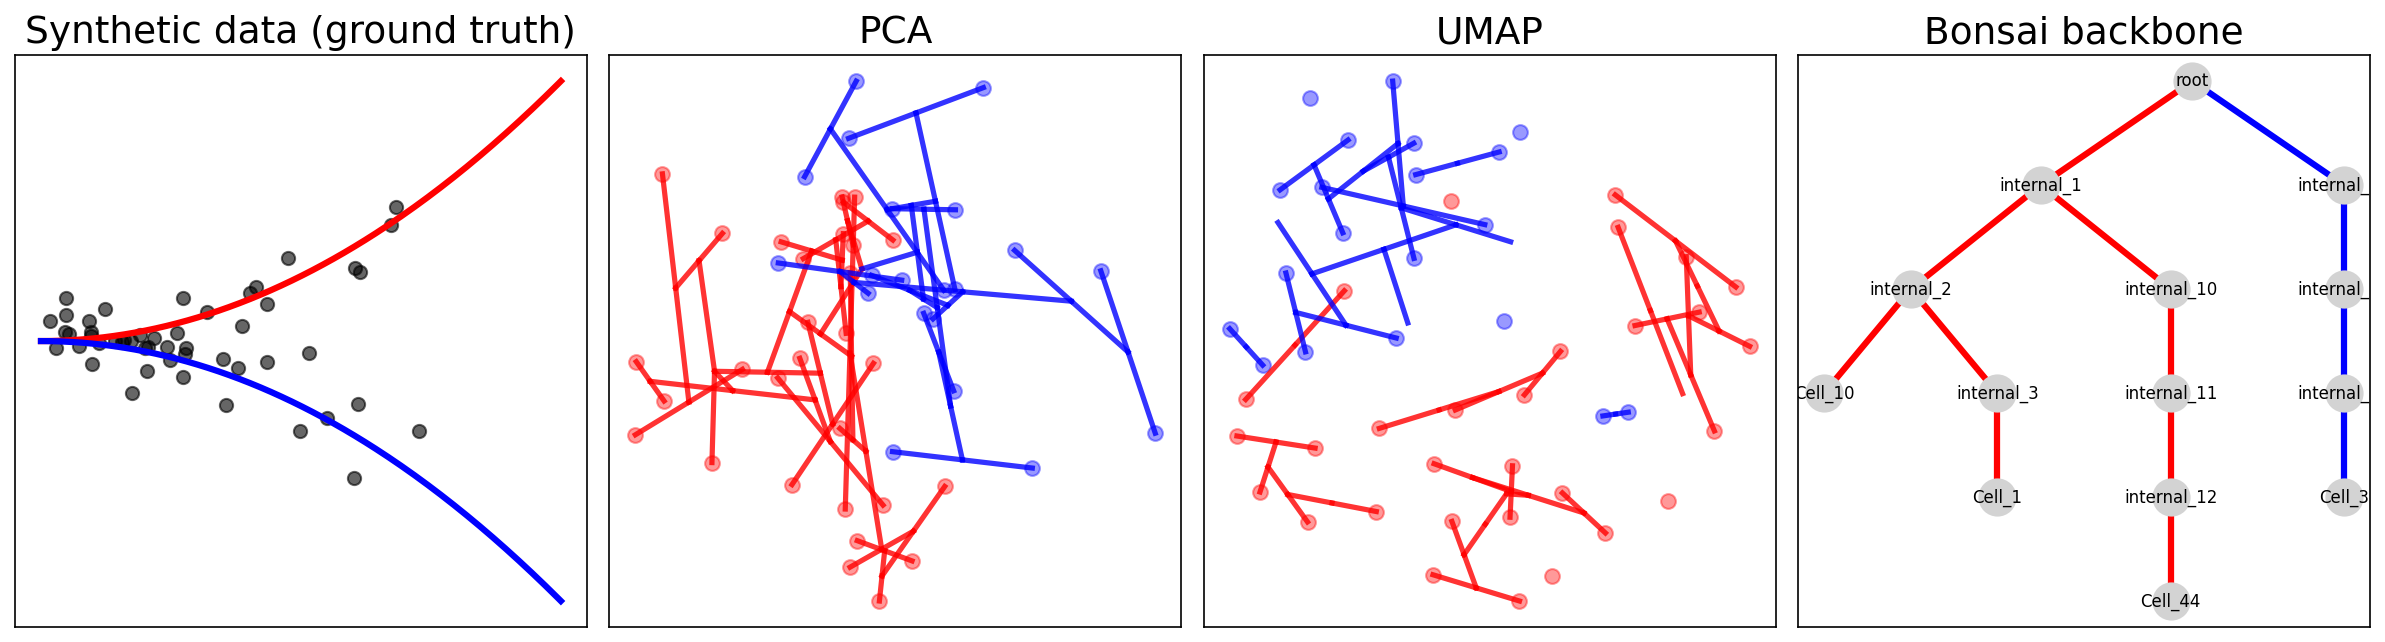

In [21]:
# Combined plot of this endeavour

#
# helpers to make the plots more interpretable
#
from src.visualize import embedding_positions, draw_projected_tree, extract_root_lineages, \
                          subtree_color, hierarchical_layout_centered, draw_tree_on_embedding
                          
#
# prepare the elements of the plot
#
lineages = extract_root_lineages(tree)
print("Number of major branches:", len(lineages))

# Assign each cell to a lineage
branch_id = np.zeros(len(data), dtype=int)
for b, lineage in enumerate(lineages):

    for cell_name in lineage:

        idx = int(cell_name.split("_")[1])
        branch_id[idx] = b

# calculate depth to control the vertical position of the branches in the final plot
depth = dict(nx.single_source_shortest_path_length(backbone_graph, "root"))

pos = hierarchical_layout_centered(tree, backbone_graph)

# use a consistent colour map for all subplots
colors = ["red","blue","green","orange","purple"]
color_map = [colors[b] for b in branch_id]

#
# Create the plot
#
fig, axes = plt.subplots(1,4,figsize=(16,4.5),dpi=150)

# ------------------------------------------------
# 1 Synthetic data + ground truth branches
# ------------------------------------------------

axes[0].scatter(data[:,0], data[:,1], s=40, color="black", alpha=0.6)

# draw true branches

t = np.linspace(0,1,200)

branch0 = np.stack([t, 0.6*t**2], axis=1)
branch1 = np.stack([t,-0.6*t**2], axis=1)

axes[0].plot(branch0[:,0], branch0[:,1], color=colors[0], linewidth=3)
axes[0].plot(branch1[:,0], branch1[:,1], color=colors[1], linewidth=3)

axes[0].set_title("Synthetic data (ground truth)", fontsize=18)
axes[0].set_box_aspect(1)

# ------------------------------------------------
# 2 PCA colored by lineage
# ------------------------------------------------

for b in range(len(lineages)):

    mask = branch_id == b

    axes[1].scatter(
        pca[mask,0],
        pca[mask,1],
        color=colors[b % len(colors)],
        s=50,
        alpha=0.4,
        label=f"B{b+1}"
    )
# draw_tree_on_embedding(axes[1], pca, tree, color_map)
pos_pca = embedding_positions(tree, pca)
draw_projected_tree(axes[1], tree, pos_pca, color_map, max_length=0.7)

axes[1].set_title("PCA", fontsize=18)
axes[1].set_box_aspect(1)


# ------------------------------------------------
# 3 UMAP colored by lineage
# ------------------------------------------------

for b in range(len(lineages)):

    mask = branch_id == b

    axes[2].scatter(
        um[mask,0],
        um[mask,1],
        color=colors[b % len(colors)],
        s=50,
        alpha=0.4
    )
# draw_tree_on_embedding(axes[2], um, tree, color_map)
pos_um = embedding_positions(tree, um)
draw_projected_tree(axes[2], tree, pos_um, color_map, max_length=0.7)

axes[2].set_title("UMAP", fontsize=18)
axes[2].set_box_aspect(1)


# ------------------------------------------------
# 4 Bonsai tree (backbone)
# ------------------------------------------------

for parent, child in backbone_graph.edges():

    x1, y1 = pos[parent]
    x2, y2 = pos[child]

    node = tree.search_nodes(name=child)[0]
    color = subtree_color(node,branch_id,colors)
    axes[3].plot([x1, x2], [y1, y2], color=color, linewidth=3)

nx.draw_networkx_nodes(
    backbone_graph,
    pos,
    ax=axes[3],
    node_color="lightgray",
    node_size=300
)

nx.draw_networkx_labels(
    backbone_graph,
    pos,
    ax=axes[3],
    font_size=8
)

axes[3].set_title("Bonsai backbone", fontsize=18)
axes[3].set_box_aspect(1)

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.savefig("../figures/bonsai_overview.png")
plt.show()

# **Quantitative evaluation**

(because of the different objectives of PCA/UMAP and Bonsai, respectively, this does not make much sense)

In [22]:
# compute pairwise distances
from sklearn.metrics import pairwise_distances
from scipy.stats import pearsonr

D_true = pairwise_distances(data)

D_pca = pairwise_distances(pca)
D_umap = pairwise_distances(um)

In [23]:
#
# Postprocess -- we will only need the distances for the leaf nodes
#

# identify leaf nodes
leaf_names = [leaf.name for leaf in tree.iter_leaves()]

# ---------- build graph ----------
G = nx.Graph()

for node in tree.traverse():
    for child in node.children:
        G.add_edge(node.name, child.name, weight=child.dist)

# map the leafs to graph nodes
leaf_nodes = [n for n in G.nodes if n in leaf_names]

# compute Bonsai distances only for leaves
n = len(leaf_nodes)

D_bonsai_leaves_only = np.zeros((n,n))

for i,n1 in enumerate(leaf_nodes):

    lengths = nx.single_source_dijkstra_path_length(G, n1)

    for j,n2 in enumerate(leaf_nodes):

        D_bonsai_leaves_only[i,j] = lengths.get(n2,0)


In [24]:
# flatten matrices for comparison
def flatten_upper(M):
    return M[np.triu_indices_from(M, k=1)]

# compute correlations
def distance_preservation(D_true, D_rep):

    x = flatten_upper(D_true)
    y = flatten_upper(D_rep)

    return pearsonr(x,y)[0]

# compute scores
scores = {
    "PCA": distance_preservation(D_true, D_pca),
    "UMAP": distance_preservation(D_true, D_umap),
    "Bonsai": distance_preservation(D_true, D_bonsai_leaves_only)
}

print(scores)

{'PCA': np.float64(0.5843094490729712), 'UMAP': np.float64(0.2863001734803347), 'Bonsai': np.float64(-0.05431750157483357)}


In [25]:
# Of course. Bonsai does not even want to preserve distances. Nor would PCA and UMAP preserve the topology.